<font size=10>**GENERAL DATA PREPROCESSING**</font> <a class="anchor" id='title'></a> 


*«notebook description»*

<u>Text Structure</u> + <u>Vocabulary</u>

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Text Structure](#3)
- [4. General Text Preprocessing](#4)
- [5. Vocabulary](#5)
- [6. Feature Extraction](#6)
    - [6.1 TF-IDF](#6_1)
    - [6.2 Counter](#6_2)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
import sys
import os
import pandas as pd

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from general_preprocessing import *
from visualizations import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [3]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [4]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [5]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [6]:
dataset = dataset_original.copy()

In [7]:
# keep a fixed example
dataset['text'].sample(1, random_state=12).values

array(['Had my hubby\'s 75th Birthday at McKendrick\'s, and it was absolutely FABULOUS!! as is dinner, there ALWAYS!! Yepper it\'s always great, all the time..you can\'t say that about many places in Atlanta.The food is excellent, no matter what you order..and it\'s Just Classy! Carol was just the best, she helped us plan the menu as well as how much we needed... just a doll. And Brian was great getting all the details down pat. If your looking for a fantastic waiter, you can\'t go wrong with Dave Harper, Dobbs, or"MIKE the waiter"..all of them are first class and funny! Thank You McKendrick\'s for making this nite, so special! And Happy New Year to you all!'],
      dtype=object)

# <font color='#BFD72F' size=6>**3. Text Structure**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

In [8]:
# TODO: See how many sentences do we have in the 'review_text' column
dataset['num_sentences'] = dataset['text'].apply(lambda x: len(str(x).split('. ')))

In [9]:
dataset['num_sentences'].describe()

count    53566.000000
mean         2.783071
std          2.657222
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         43.000000
Name: num_sentences, dtype: float64

In [ ]:
histogram_chart(
    data=dataset,
    column='num_sentences',
    title='Number of Sentences per Review',
    x_label='Number of Sentences'
)

# <font color='#BFD72F' size=6>**4. General Text Preprocessing**</font> <a class="anchor" id="4"></a>
  
[Back to TOC](#toc)

1. **Clean data** - remove extraneous content.

2. **Transform data** - tokenization, POS tagging, stopwords removal.

3. **Normalize data** - case, stemming, and lemmatization.


*NOTE*:

It is better to tokenize first and then remove punctuation, as some punctuation marks may be part of words (e.g., "don't", "it's").
This way, we can preserve the integrity of words while still removing unwanted punctuation.

In [10]:
# 1️⃣ CLEAN DATA — remove extraneous content
dataset['01_cleaned_text'] = dataset['text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=False,              # we’ll remove them later
        stopwords_tokeep=['again'],
        extra_stopwords=[],
        convert_diacritics=True,
        lowercase=False,                 # normalization step later
        lemmatized=False,
        list_pos=[],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,
        no_hashtags=True,
        hashtag_retain_words=True,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,
        treat_repeated_chars=True
    )
)

In [11]:
# 2️⃣ TRANSFORM DATA — tokenization, POS tagging, stopwords removal
dataset['02_transformed_text'] = dataset['01_cleaned_text'].apply(
    lambda x: main_pipeline(
        raw_text=x,
        no_stopwords=True,
        stopwords_tokeep=['again'],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=False,
        lemmatized=False,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [12]:
# 3️⃣ NORMALIZE DATA — case normalization, stemming, lemmatization
dataset['03_normalized_text'] = dataset['02_transformed_text'].apply(
    lambda x: main_pipeline(
        raw_text=' '.join(x) if isinstance(x, list) else x,
        no_stopwords=False,              # already removed
        stopwords_tokeep=[],
        extra_stopwords=[],
        convert_diacritics=False,
        lowercase=True,
        lemmatized=True,
        list_pos=['n', 'v', 'a', 'r', 's'],
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=True,
        no_emojis=False,
        no_hashtags=False,
        hashtag_retain_words=True,
        no_newlines=False,
        no_urls=False,
        no_punctuation=False,
        treat_repeated_chars=False
    )
)

In [31]:
# Follow an example

print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=12).values)

print("\nCleaned Text Sample:\n")
print(dataset[['01_cleaned_text']].sample(1, random_state=12).values)

print("\nTransformed Text Sample:\n")
print(dataset[['02_transformed_text']].sample(1, random_state=12).values)

print("\nNormalized Text Sample:\n")
print(dataset[['03_normalized_text']].sample(1, random_state=12).values)


Original Text Sample:

[['Had my hubby\'s 75th Birthday at McKendrick\'s, and it was absolutely FABULOUS!! as is dinner, there ALWAYS!! Yepper it\'s always great, all the time..you can\'t say that about many places in Atlanta.The food is excellent, no matter what you order..and it\'s Just Classy! Carol was just the best, she helped us plan the menu as well as how much we needed... just a doll. And Brian was great getting all the details down pat. If your looking for a fantastic waiter, you can\'t go wrong with Dave Harper, Dobbs, or"MIKE the waiter"..all of them are first class and funny! Thank You McKendrick\'s for making this nite, so special! And Happy New Year to you all!']]

Cleaned Text Sample:

[['Had my hubbys 75th Birthday at McKendricks and it was absolutely FABULOUS as is dinner there ALWAYS Yepper its always great all the cant say that about many places in AtlantaThe food is excellent no matter what you its Just Classy Carol was just the best she helped us plan the menu as 

In [15]:
dataset['token_count'] = dataset['02_transformed_text'].apply(len)

histogram_chart(
    data=dataset,
    column='token_count',
    title='Token Count per Review',
    x_label='Number of Tokens'
)

In [16]:
dataset['review_char_len'] = dataset['text'].astype(str).str.len()

histogram_chart(
    data=dataset,
    column='review_char_len',
    title='Review Length (Characters)',
    x_label='Number of Characters'
)

# <font color='#BFD72F' size=6>**5. Vocabulary**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

In [17]:
corpus = dataset['03_normalized_text'].explode()
print(f'Corpus Size: {len(corpus)}')
corpus

Corpus Size: 966122


0          one
0         word
0        amaze
0          red
0         fish
         ...  
53565    space
53565    table
53565     live
53565    music
53565     back
Name: 03_normalized_text, Length: 966122, dtype: object

In [18]:
vocabulary = corpus.unique()
print(f'Vocabulary Size: {len(vocabulary)}')
vocabulary

Vocabulary Size: 25380


array(['one', 'word', 'amaze', ..., 'tartufo', 'ryleigh', 'francaise'],
      dtype=object)

# <font color='#BFD72F' size=6>**6. Feature Extraction**</font> <a class="anchor" id="6"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>6.1 TF-IDF</font> <a class="anchor" id="6_1"></a>
  
[Back to TOC](#toc)

In [21]:
tfidf_text, tfidf_vectorizer = vectorize_texts(dataset['03_normalized_text'])
tfidf_df = pd.DataFrame(tfidf_text.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [22]:
tfidf_df.sample(1, random_state=12)

,10,100,1010,12,15,1st,20,25,30,40,...,yes,yesterday,yet,york,youll,young,youre,yum,yummy,zero
11414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
tfidf_means = tfidf_df.mean(axis=0).sort_values(ascending=False).head(20)
tfidf_top_df = pd.DataFrame({
    'token': tfidf_means.index,
    'tfidf_weight': tfidf_means.values
})
bar_chart(
    data=tfidf_top_df,
    x='token',
    y='tfidf_weight',
    title='Top 20 tokens by TF-IDF weight',
    labels={'token': 'Token', 'tfidf_weight': 'Average TF-IDF Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds\\tfidf_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x16d95ce8850>}

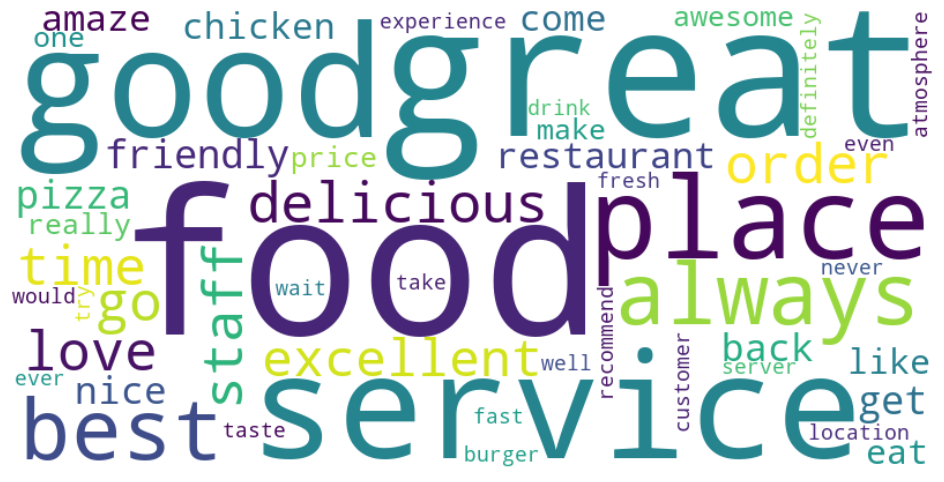

In [24]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='tfidf_vectorization.png',
    vectorized_df=tfidf_df,
    top_n=50
)

In [25]:
cooc_matrix_tfidf = cooccurrence_matrix(tfidf_df, sentence_cooc=False, window_size=5)

Computing co-occurrences: 100%|██████████| 53566/53566 [00:05<00:00, 10287.86it/s]


In [26]:
display(cooc_matrix_tfidf)

,food,good,service,order,go,great,get,time,place,back,...,que,un,ashley,en,servicio,lugar,atencion,buena,excelente,buen
food,0,8243,9505,3293,3923,8660,3413,3653,4311,3177,...,7,17,34,12,5,2,2,1,6,2
good,8243,0,4835,2156,2346,3250,2313,2246,2728,1813,...,5,8,12,2,0,0,2,1,4,1
service,9505,4835,0,1948,2241,6248,1929,2192,2288,2004,...,8,9,37,7,6,2,2,0,5,1
order,3293,2156,1948,0,2163,1291,2391,2156,1727,1484,...,6,6,3,4,1,1,0,0,0,0
go,3923,2346,2241,2163,0,1846,2098,2122,2009,2267,...,4,3,13,4,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lugar,2,0,2,1,1,0,0,1,3,1,...,39,46,0,36,31,0,21,16,40,33
atencion,2,2,2,0,0,1,0,1,0,0,...,23,19,0,20,17,21,0,55,42,14
buena,1,1,0,0,0,1,0,1,0,0,...,20,19,0,25,26,16,55,0,21,20
excelente,6,4,5,0,1,1,0,0,1,1,...,20,29,0,20,57,40,42,21,0,17


## <font color='#BFD72F' size=6>6.2 Counter</font> <a class="anchor" id="6_2"></a>
  
[Back to TOC](#toc)

In [27]:
counter_text, counter_vectorizer = vectorize_texts(
    dataset['03_normalized_text'], vectorizer_type='count'
)
counter_df = pd.DataFrame(counter_text.toarray(), columns=counter_vectorizer.get_feature_names_out())

In [28]:
counter_df.sample(1, random_state=12)

,10,100,1010,12,15,1st,20,25,30,40,...,yes,yesterday,yet,york,youll,young,youre,yum,yummy,zero
11414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
counter_means = counter_df.mean(axis=0).sort_values(ascending=False).head(20)
counter_top_df = pd.DataFrame({
    'token': counter_means.index,
    'counter_weight': counter_means.values
})
bar_chart(
    data=counter_top_df,
    x='token',
    y='counter_weight',
    title='Top 20 tokens by Counter weight',
    labels={'token': 'Token', 'counter_weight': 'Average Counter Weight'},
    top_n=20
)

{'path': '../images/visualizations/wordclouds\\counter_vectorization.png',
 'wordcloud': <wordcloud.wordcloud.WordCloud at 0x16d97e27220>}

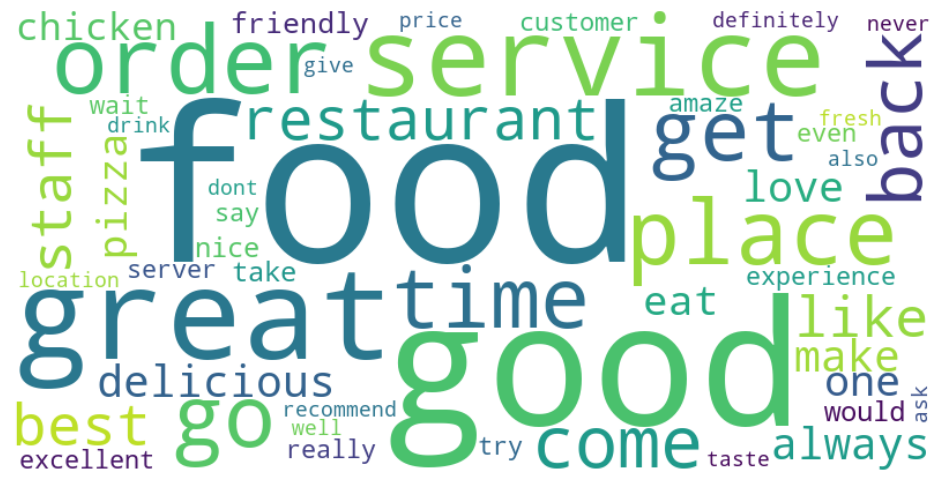

In [30]:
wordcloud_from_vectorized(
    folder_path='../images/visualizations/wordclouds',
    filename='counter_vectorization.png',
    vectorized_df=counter_df,
    top_n=50
)